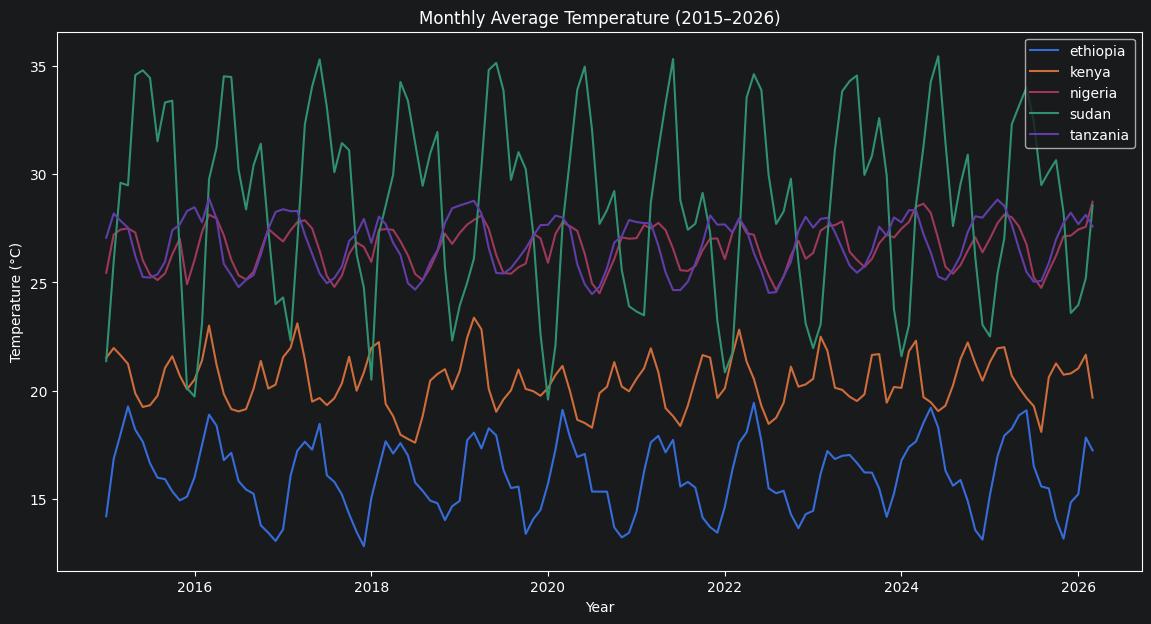

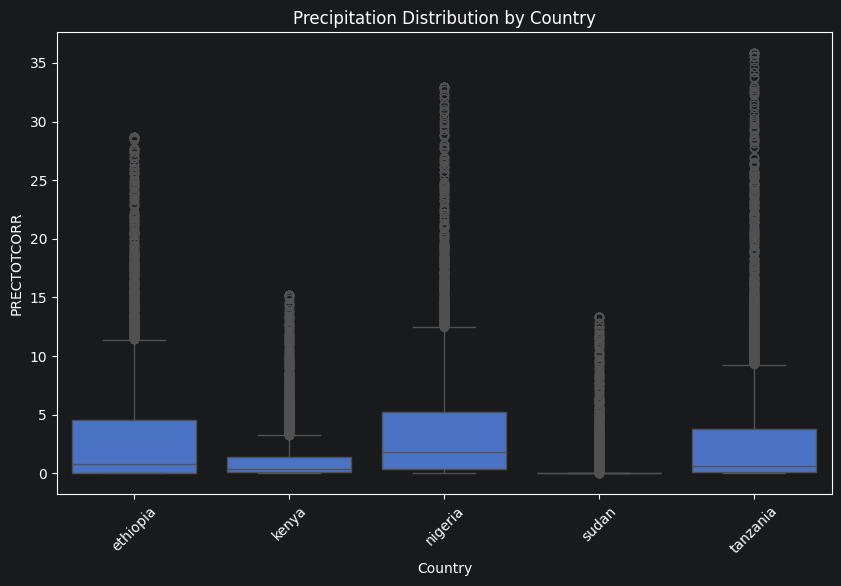

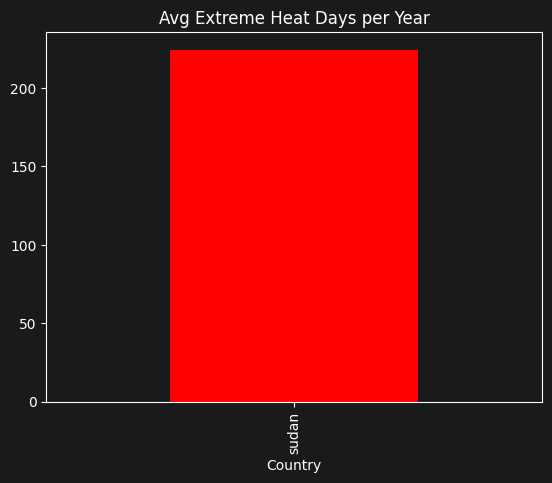

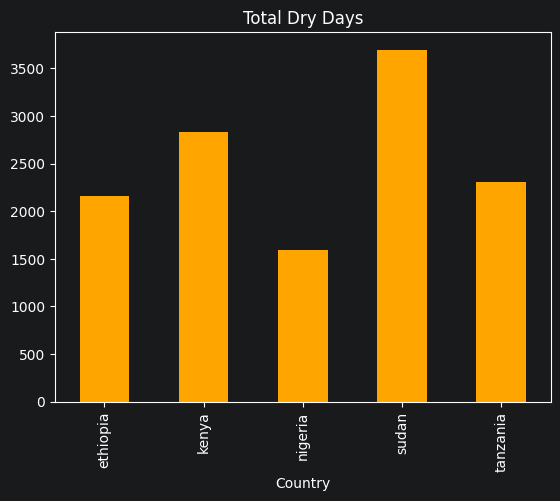

ANOVA p-value: 0.0
Kruskal p-value: 0.0


,Temp_Mean,Rain_Variability,Extreme_Heat,Dry_Days,Vulnerability_Score
Country,,,,,
tanzania,0.845516,1.000000,NaN,0.336982,0.727499
sudan,1.000000,0.000000,NaN,1.000000,0.666667
nigeria,0.834313,0.860314,NaN,0.000000,0.564876
ethiopia,0.000000,0.838615,NaN,0.269396,0.369337
kenya,0.343187,0.138949,NaN,0.588291,0.356809


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, kruskal

#we need to load all country
ethiopia = pd.read_csv("data/ethiopia_clean.csv")
kenya = pd.read_csv("data/kenya_clean.csv")
nigeria = pd.read_csv("data/nigeria_clean.csv")
sudan = pd.read_csv("data/sudan_clean.csv")
tanzania = pd.read_csv("data/tanzania_clean.csv")

# Combine
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania], ignore_index=True)

# Ensure datetime
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

df.head()

#Monthly average T2M (all countries)
monthly_temp = df.groupby(["Country", "Year", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(
    monthly_temp["Year"].astype(str) + "-" + monthly_temp["Month"].astype(str)
)

plt.figure(figsize=(14,7))

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Date"], subset["T2M"], label=country)

plt.legend()
plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.show()

#summary status
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary.sort_values(by="mean", ascending=False)

#Precipitation Variability
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")
plt.title("Precipitation Distribution by Country")
plt.xticks(rotation=45)
plt.show()

#Summary stats
rain_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
rain_summary.sort_values(by="std", ascending=False)

#Extreme Event Frequency Extreme heat (>35°C)

heat_extreme = df[df["T2M_MAX"] > 35]

heat_counts = heat_extreme.groupby(["Country", "Year"]).size().reset_index(name="Extreme_Heat_Days")

heat_summary = heat_counts.groupby("Country")["Extreme_Heat_Days"].mean()

heat_summary
#Consecutive dry days (<1 mm)
df["Dry"] = df["PRECTOTCORR"] < 1

dry_counts = df.groupby("Country")["Dry"].sum()

dry_counts
#Visualization
heat_summary.plot(kind="bar", title="Avg Extreme Heat Days per Year", color="red")
plt.show()

dry_counts.plot(kind="bar", title="Total Dry Days", color="orange")
plt.show()

#Statistical Testing
groups = [group["T2M"].dropna() for name, group in df.groupby("Country")]

anova_result = f_oneway(*groups)
kruskal_result = kruskal(*groups)

print("ANOVA p-value:", anova_result.pvalue)
print("Kruskal p-value:", kruskal_result.pvalue)
#Vulnerability Ranking Build scoring system
ranking = pd.DataFrame({
    "Temp_Mean": temp_summary["mean"],
    "Rain_Variability": rain_summary["std"],
    "Extreme_Heat": heat_summary,
    "Dry_Days": dry_counts
})

# Normalize (simple scaling)
ranking = (ranking - ranking.min()) / (ranking.max() - ranking.min())

# Composite score
ranking["Vulnerability_Score"] = ranking.mean(axis=1)

ranking.sort_values(by="Vulnerability_Score", ascending=False)
